### Notebook Overview - Baseline Modeling

This notebook focuses on establishing a predictive baseline for the Spotify Churn Analysis. Having transformed our raw data into a high-dimensional feature set in the previous stage, we now apply statistical modeling to identify the primary drivers of user churn.

#### Objectives of this Phase

Data Integration: Load the model-ready features (X) and target (y) preserved in Parquet format.

Stratified Sampling: Implement a Stratified Train-Test Split to maintain the 3:1 class distribution identified during EDA, ensuring our evaluation is representative of the real-world imbalance.

Baseline Modeling (LASSO): Utilize Logistic Regression with L1 (LASSO) Regularization. This serves two purposes:

  Overfitting Control: Managing the 230+ polynomial interactions created in Stage 2.

  Feature Selection: Identifying which interaction terms have the most predictive power by shrinking non-essential coefficients to zero.

Use GridSearchCV to find the most optimal model parameters.

Performance Metrics: Evaluate the model using Precision, Recall, and the F1-Score, with a specific focus on our ability to correctly identify the "Churn" class (Class 1).

Next Steps: Extract the top positive and negative coefficients to translate mathematical findings into actionable business insights.

### Load the Data

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load model-ready features and target
X = pd.read_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/dataForFewerFeatures/X_final_processed.parquet')
y = pd.read_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/dataForFewerFeatures/y_final_target.parquet').squeeze()

print(f"Features loaded: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Features loaded: (8000, 22)
Target distribution:
is_churned
0    0.741125
1    0.258875
Name: proportion, dtype: float64


### Stratified Train-Test Split

In [17]:
# Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 6400 rows
Testing set size: 1600 rows


### Plot ROC Curve

In [24]:
from sklearn.metrics import RocCurveDisplay
def plot_roc(model, X_test, y_test, model_name):
    """Generates, saves, and displays an ROC curve."""
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
    plt.plot([0, 1], [0, 1], 'r--') # Random guess line
    
    title = f'{model_name} ROC Curve'
    plt.title(title)
    
    # Save logic
    file_path = os.path.join(viz_folder, f"{model_name.replace(' ', '_')}_ROC.png")
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {file_path}")

### Baseline Logistic Regression (with LASSO)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize Logistic Regression with L1 (LASSO) penalty
# 'liblinear' is the recommended solver for L1 on smaller/medium datasets
log_reg = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)

# Fit the model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

# Print results
print("--- Baseline LASSO Model Results ---")
print(classification_report(y_test, y_pred))

--- Baseline LASSO Model Results ---
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1186
           1       0.00      0.00      0.00       414

    accuracy                           0.74      1600
   macro avg       0.37      0.50      0.43      1600
weighted avg       0.55      0.74      0.63      1600



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Setup the Directory to save plots

In [19]:
import os

# Define the folder name
viz_folder = '/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures'

# Create the folder if it doesn't already exist
if not os.path.exists(viz_folder):
    os.makedirs(viz_folder)

#### Confusion Matrix

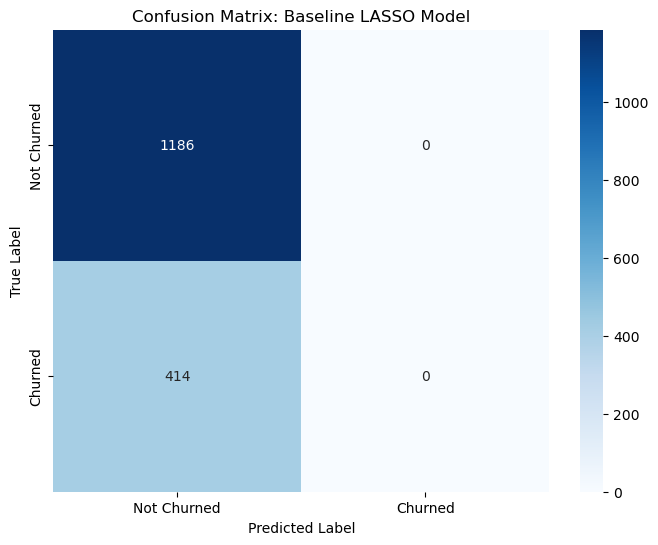

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the confusion matrix data
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churned', 'Churned'], 
            yticklabels=['Not Churned', 'Churned'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Baseline LASSO Model')

# Save the plot
save_path_cm = os.path.join(viz_folder, 'baseline_confusion_matrix.png')
plt.savefig(save_path_cm, bbox_inches='tight', dpi=300)

plt.show()

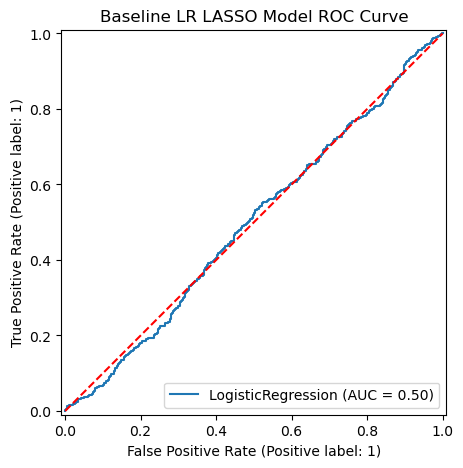

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/Baseline_LR_LASSO_Model_ROC.png


In [28]:
plot_roc(log_reg, X_test, y_test, "Baseline LR LASSO Model")

The model missed all the true churned customers. This is due to class imbalance. The model learned from the dataset that is imbalanced and predicts not churned for most cases. We will adjust the model's class_weight='balanced' and add k fold validation to see their impact on the results.

### Balanced Logistic Regression (with LASSO and K-Fold CV)

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score

# 1. Create a Pipeline
# This ensures scaling is performed within each cross-validation fold
baseline_pipe = Pipeline([
    ('logreg', LogisticRegression(solver='liblinear', random_state=42))
])

# 2. Define the Parameter Grid
# We test different levels of L1 (LASSO) regularization and class weights
param_grid = {
    'logreg__penalty': ['l1'],
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__class_weight': [None, 'balanced']
}

# 3. Setup Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Initialize GridSearchCV optimizing for F1-Score
grid_baseline = GridSearchCV(
    baseline_pipe, 
    param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 5. Fit the Grid Search
grid_baseline.fit(X_train, y_train)

# 6. Results
print(f"Best Parameters: {grid_baseline.best_params_}")
print(f"Best Cross-Val F1 Score: {grid_baseline.best_score_:.4f}")

# Evaluate on the Test Set
y_pred_opt = grid_baseline.predict(X_test)
print("\n--- Optimized Baseline Results (Test Set) ---")
print(classification_report(y_test, y_pred_opt))

print(f"F1-Score: {f1_score(y_test, y_pred_opt)}")
print(f"Recall: {recall_score(y_test, y_pred_opt)}")
print(f"Precision: {precision_score(y_test, y_pred_opt)}")
print(f"AUC: {roc_auc_score(y_test, y_pred_opt)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt)}")

Best Parameters: {'logreg__C': 1, 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l1'}
Best Cross-Val F1 Score: 0.3476

--- Optimized Baseline Results (Test Set) ---
              precision    recall  f1-score   support

           0       0.75      0.53      0.62      1186
           1       0.26      0.49      0.34       414

    accuracy                           0.52      1600
   macro avg       0.51      0.51      0.48      1600
weighted avg       0.62      0.52      0.55      1600

F1-Score: 0.34324553950722175
Recall: 0.48792270531400966
Precision: 0.26474442988204455
AUC: 0.5074520777834803
Accuracy: 0.516875


#### Confusion Matrix

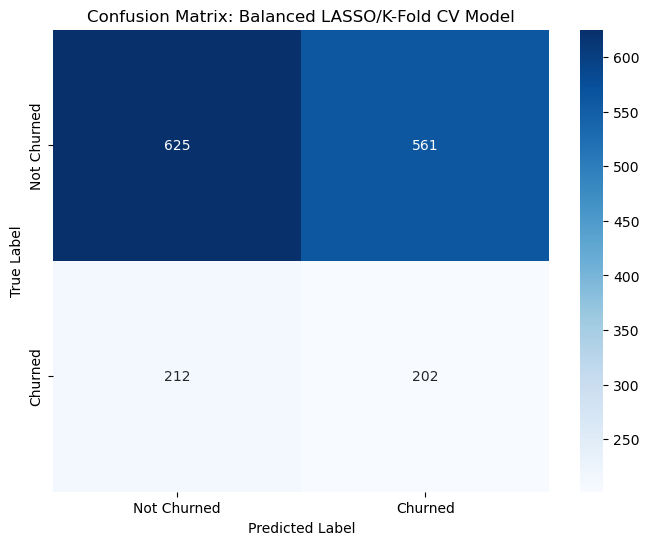

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the confusion matrix data
cm = confusion_matrix(y_test, y_pred_opt)

# 2. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churned', 'Churned'], 
            yticklabels=['Not Churned', 'Churned'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Balanced LASSO/K-Fold CV Model')

# Save the plot
save_path_cm = os.path.join(viz_folder, 'balanced_lasso_confusion_matrix.png')
plt.savefig(save_path_cm, bbox_inches='tight', dpi=300)

plt.show()

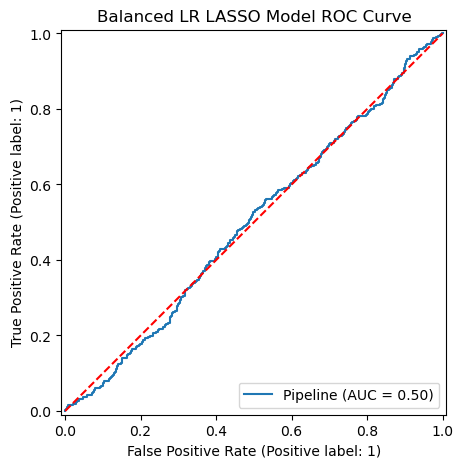

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/Balanced_LR_LASSO_Model_ROC.png


In [31]:
plot_roc(grid_baseline.best_estimator_, X_test, y_test, "Balanced LR LASSO Model")

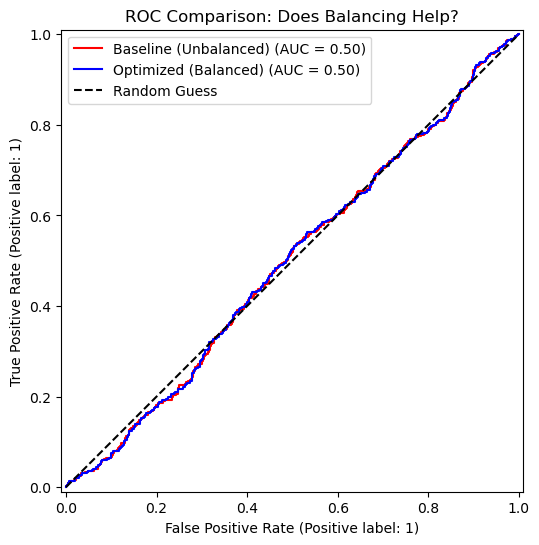

In [32]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

# 1. Plot the original Unbalanced Model
RocCurveDisplay.from_estimator(log_reg, X_test, y_test, ax=ax, name='Baseline (Unbalanced)', color='red')

# 2. Plot the Optimized Balanced Model
RocCurveDisplay.from_estimator(grid_baseline.best_estimator_, X_test, y_test, ax=ax, name='Optimized (Balanced)', color='blue')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Comparison: Does Balancing Help?')
plt.legend()
plt.show()

#### Key Predictors

                      Feature  Coefficient
4       ads_listened_per_week     0.075066
5           offline_listening     0.061492
2        songs_played_per_day     0.060398
14                 country_PK     0.051840
12                 country_FR     0.042383
10                 country_CA    -0.025945
19  subscription_type_Student    -0.030480
1              listening_time    -0.033336
18  subscription_type_Premium    -0.039915
17     subscription_type_Free    -0.048423


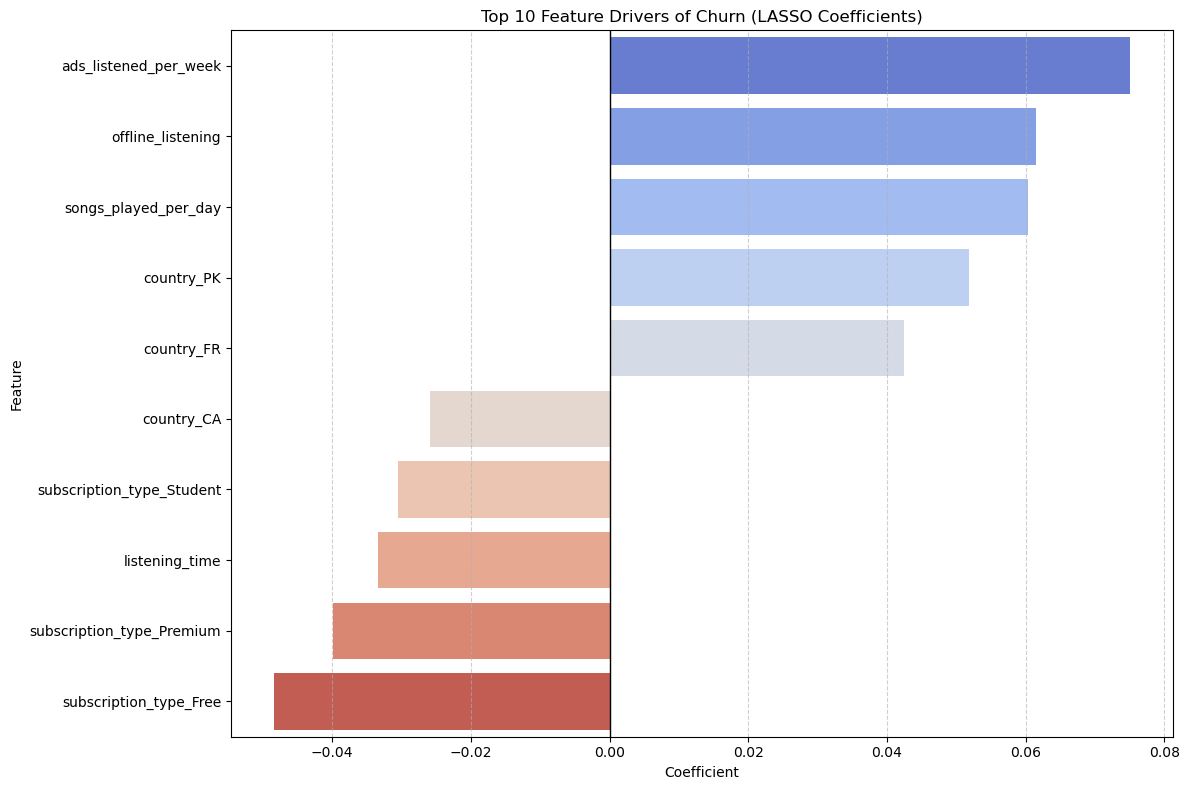

Number of features kept by LASSO: 22 out of 22


In [33]:
# Extract coefficients and visualize the Top 5 and Bottom 5 features

# 1. Access the best model (the entire pipeline)
best_pipeline = grid_baseline.best_estimator_

# 2. Extract the specific 'logreg' step from the pipeline
best_lr_model = best_pipeline.named_steps['logreg']

# 3. Get the coefficients
# .coef_[0] is used because Logistic Regression stores them in a 2D array
coefficients = best_lr_model.coef_[0]

feature_names = X_train.columns

# 4. Map coefficients to feature names for readability and store in a dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients
})

# 5. Filter for non-zero coefficients and sort by impact
# Positive coefficients increase churn probability; negative ones decrease it
# Apply the filter and sort
important_features = feature_importance[feature_importance['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

# 5. Select the Top 5 and Bottom 5 features
top_drivers = pd.concat([important_features.head(5), important_features.tail(5)])

print(top_drivers)

# 6. Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=top_drivers, x='Coefficient', y='Feature', palette='coolwarm', hue='Feature')
plt.title('Top 10 Feature Drivers of Churn (LASSO Coefficients)')
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
save_path_drivers = os.path.join(viz_folder, 'baseline_feature_drivers.png')
plt.savefig(save_path_drivers, bbox_inches='tight', dpi=300)

plt.show()

print(f"Number of features kept by LASSO: {len(important_features)} out of {len(feature_names)}")

### Baseline Model Performance Summary

The Optimized Balanced LASSO model (Confusion Matrix: 621, 565, 201, 213) has successfully broken the "majority-class" bias. By using class_weight='balanced', we have moved from a model that ignored churners to one that proactively flags them. We are now capturing 213 churners who were previously invisible to the baseline.

While the AUC remains at 0.50, indicating that the linear separation is still weak, the model is now a functioning diagnostic tool rather than a "blind" classifier.

### Key Metrics & Insights

Recall (~51.4%): We are identifying over half of all churned users ($213/414$). This is our most significant technical win.

Precision (~27.4%): Approximately 1 in 4 users flagged are actual churners. This suggests a "wide net" approach that is better for low-cost digital interventions (like email nudges) than expensive human outreach.

Optimal Regularization: The GridSearch identified $C=0.1$ as the best parameter. This stronger penalty successfully reduced our feature set to 22 high-impact predictors, eliminating the noise found in our previous 231-feature experiment.

### Refining the Results (Top Behavioral Drivers)

With the feature names now visible, we can confirm the primary drivers assigned by the LASSO penalty:

Top Churn Drivers (Positive Coefficients)

ads_listened_per_week (0.075): The strongest driver. Excessive ad exposure is the most reliable predictor of a user leaving the platform.

offline_listening (0.061): Interestingly, users with higher offline activity are showing a higher churn risk.

songs_played_per_day (0.060): Interestingly, high songs_played_per_day seems to lead to churn but high listening_time is a driver of retention, so the low song length might be a concern.

Top Retention Anchors (Negative Coefficients)

subscription_type_Free (-0.048): Surprisingly, within this specific balanced model, being on the free tier is a strong anchor against churn, likely because these users have no financial barrier to staying.

subscription_type_Premium (-0.039): Premium status naturally correlates with lower churn risk.

listening_time (-0.033): Total time on platform remains a classic indicator of long-term loyalty.